In [254]:
import sys
print(sys.version)
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
import shap
import xgboost, lightgbm, catboost
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GroupKFold, KFold, GroupShuffleSplit, train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

3.9.19 (main, May  6 2024, 20:12:36) [MSC v.1916 64 bit (AMD64)]


In [256]:
# =========================
# 0) Environment and parameters
# =========================
warnings.filterwarnings("ignore")
BASE_DIR = "./Data"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# =========================
# 1) Utility functions
# =========================
def _clean_sample_series(s: pd.Series) -> pd.Series:
    """Standardize Sample column: convert to string and remove whitespace."""
    return s.astype(str).str.strip()

def read_table_with_sample(path, prefix=None):
    """Read table with Sample column or treat the first column as Sample; optionally add prefix to non-Sample columns."""
    df = pd.read_csv(path)

    out = df.copy()
    if "Sample" not in out.columns:
        out.rename(columns={out.columns[0]: "Sample"}, inplace=True)

    out["Sample"] = _clean_sample_series(out["Sample"])

    if prefix:
        new_cols = ["Sample"] + [f"{prefix}{c}" for c in out.columns if c != "Sample"]
        out.columns = new_cols

    return out

def read_core_genes(path):
    """Read core genes: prioritize 'Gene' or 'SYMBOL' column, otherwise use the first column."""
    df = pd.read_csv(path)
    if "Gene" in df.columns:
        genes = df["Gene"]
    elif "SYMBOL" in df.columns:
        genes = df["SYMBOL"]
    else:
        genes = df.iloc[:, 0]

    genes = genes.astype(str).str.strip()
    genes = genes[genes.notna()].unique().tolist()
    return genes

def read_neuron_expr(path):
    """
    Read expression matrix neuron.csv:
    - First column is Sample, remaining columns are gene expression
    - Return DataFrame with rows=Sample and columns=Gene (all numeric, non-numeric converted to NaN)
    """
    df = pd.read_csv(path)

    if "Sample" not in df.columns:
        df.rename(columns={df.columns[0]: "Sample"}, inplace=True)

    df["Sample"] = _clean_sample_series(df["Sample"])

    gene_cols = [c for c in df.columns if c != "Sample"]

    # Standardize column names as strings and remove duplicates (keep first occurrence)
    genes_str = pd.Index([str(c).strip() if pd.notna(c) else "NA_col" for c in gene_cols])
    keep_mask = ~genes_str.duplicated(keep="first")

    kept_gene_cols = [gc for gc, keep in zip(gene_cols, keep_mask) if keep]
    genes_str = genes_str[keep_mask]

    X = df[["Sample"] + kept_gene_cols].copy()
    X.columns = ["Sample"] + list(genes_str)

    # Convert to numeric
    num_part = X.drop(columns=["Sample"]).apply(pd.to_numeric, errors="coerce")
    X = pd.concat([X[["Sample"]], num_part], axis=1)

    X = X.set_index("Sample")
    X.index.name = "Sample"
    return X

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# =========================
# 2) Paths and data loading
# =========================
meta_path   = os.path.join(BASE_DIR, "Meta_info.csv")
sex_path    = os.path.join(BASE_DIR, "ALLSEX_raw.csv")
cell_path   = os.path.join(BASE_DIR, "ALLCELL.csv")
ssgsea_path = os.path.join(BASE_DIR, "ALLgsea_batchZ.csv")
core_path   = os.path.join(BASE_DIR, "core.csv")
neuron_path = os.path.join(BASE_DIR, "DIS_AGE_Combat_exp2.csv")
reo_path = os.path.join(BASE_DIR, "ALLREO_batchZ.csv")

# meta
meta = pd.read_csv(meta_path)

need_cols = ["Sample", "AGE", "DIS_HEA", "Batch", "Deg", "timepoint", "Sample.1"]
missing = sorted(set(need_cols) - set(meta.columns))
assert not missing, f"meta missing columns: {missing}"
meta["Sample"] = _clean_sample_series(meta["Sample"])


sex_df     = read_table_with_sample(sex_path,    prefix=None)
cell_df    = read_table_with_sample(cell_path,   prefix="imm__")
ssgsea_df  = read_table_with_sample(ssgsea_path, prefix="ssgsea__")
core_genes = read_core_genes(core_path)
reo_df = read_table_with_sample(reo_path, prefix=None)
reo_df.rename(columns={"REO_score": "REO"}, inplace=True)
expr_SxG = read_neuron_expr(neuron_path)
expr_SxG = expr_SxG.reindex(meta["Sample"].values)

if len(core_genes) > 0:
    core_present = [g for g in core_genes if g in expr_SxG.columns]
    if len(core_present) == 0:
        print("WARNING: core_genes do not match expression matrix columns, fallback to all genes.")
        core_present = list(expr_SxG.columns)
else:
    core_present = list(expr_SxG.columns)

expr_core = expr_SxG[core_present].copy()
expr_core.columns = [f"g__{c}" for c in expr_core.columns]
expr_core = expr_core.reset_index()

# =========================
# 3) Assemble feature table dat
# =========================
def merge_overwrite(left, right, key="Sample"):
    """
    Merge tables; if overlapping columns exist (except key),
    prioritize values from the right table but keep left values if right is NaN.
    """
    overlap = [c for c in right.columns if c != key and c in left.columns]
    if overlap:
        out = left.merge(right, on=key, how="left", suffixes=("", "_r"))
        for c in overlap:
            out[c] = out[f"{c}_r"].combine_first(out[c])
            out.drop(columns=[f"{c}_r"], inplace=True)
        return out
    else:
        return left.merge(right, on=key, how="left")

# Merge base information, auxiliary tables, and core expression
base_cols = [
    "Sample",
    "AGE",
    "DIS_HEA",
    "Batch",
    "Deg",
    "timepoint",
    "Sample.1",
    "Weight_loss",
]
dat = meta[base_cols].copy()

# Ensure Sample columns are standardized before merging
for _df in (sex_df, cell_df, ssgsea_df, reo_df, expr_core):
    if "Sample" in _df.columns:
        _df["Sample"] = _clean_sample_series(_df["Sample"])

dat = merge_overwrite(dat, sex_df)
dat = merge_overwrite(dat, cell_df)
dat = merge_overwrite(dat, ssgsea_df)
dat = merge_overwrite(dat, reo_df)
dat = merge_overwrite(dat, expr_core)

if "Sex" in dat.columns:
    dat["Sex"] = dat["Sex"].astype(str)
if "REO" in cols:
    candidates.append("REO")

In [257]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# =========================
# 1) Healthy samples
# =========================
dat_healty = dat[dat["DIS_HEA"] == "HEA"].copy()
dat_healty["Batch"] = dat_healty["Batch"].astype(str).str.strip()


# =========================
# 2) External, internal-external, and DEF-external datasets
# =========================
EXTERNAL_BATCHES = [
    "ETES1(Influenza1)",
    "ETES2(Influenza2)",
    "ETES3(Influenza3)",
    "ETES4(Major depressive Disease samplesorder1)",
    "ETES5(Major depressive Disease samplesorder2)",
    "ETES6(Covid-19-1)",
    "ETES7(Covid-19-2)",
    "ETES8(Covid-19-3)",
    "ETES9(Covid-19-4)"
]

DEF_EXTERNAL_BATCHES = [
    "ES1(Sepsis)",
    "ES2(Weight loss)",
    "ES3(LongCovid19)",
    "ES4(Pre-post Covid19)",
]

INT_EXT_BATCH = "ETS1"

# DEF-external has the highest priority:
# these samples are extracted first and do not participate in any split.
def_external_mask = dat_healty["Batch"].isin(DEF_EXTERNAL_BATCHES)

# EXT excludes all DEF-external samples, including overlapping Batch names.
ext_mask = (
    ~def_external_mask
    & dat_healty["Batch"].isin(EXTERNAL_BATCHES)
)

# INT_EXT also excludes DEF-external and EXT samples.
int_ext_mask = (
    ~def_external_mask
    & ~ext_mask
    & dat_healty["Batch"].eq(INT_EXT_BATCH)
)

def_external_df = dat_healty[def_external_mask].copy()
test_df = dat_healty[ext_mask].copy()
int_ext_df = dat_healty[int_ext_mask].copy()

train_pool_df = dat_healty[
    ~def_external_mask
    & ~ext_mask
    & ~int_ext_mask
].copy()

# =========================
# 3) Select features
# =========================
drop_cols = ["Sample", "AGE", "Batch", "DIS_HEA"]
cols = dat_healty.columns

candidates = (
    [c for c in cols if c.startswith("imm__")]
    + [c for c in cols if c.startswith("g__")]
    + [c for c in cols if c.startswith("ssgsea__")]
)

if "REO" in cols:
    candidates.append("REO")

if "Male" in cols:
    candidates.append("Male")

feature_cols = sorted(
    set(c for c in candidates if c not in drop_cols)
)


# =========================
# 4) Prepare datasets
# =========================
X_all = train_pool_df[feature_cols].copy()
y_all = train_pool_df["AGE"].astype(float).values

X_ext_raw = test_df[feature_cols].copy()
y_ext = test_df["AGE"].astype(float).values

X_int_ext_raw = int_ext_df[feature_cols].copy()
y_int_ext = int_ext_df["AGE"].astype(float).values


# =========================
# 5) Split functions
# =========================
def collapse_rare_strata(strata, batches, min_count=2):
    strata = strata.astype(str).copy()
    batches = batches.astype(str).copy()

    rare = strata.value_counts()[lambda x: x < min_count].index
    rare_mask = strata.isin(rare)
    strata.loc[rare_mask] = batches.loc[rare_mask]

    rare = strata.value_counts()[lambda x: x < min_count].index
    strata.loc[strata.isin(rare)] = "OTHER"

    return strata


def build_strata(dataframe, n_bins):
    meta = dataframe[["Batch", "AGE"]].copy()
    meta["Batch"] = meta["Batch"].astype(str).str.strip()

    bins = min(n_bins, max(2, meta.shape[0] // 10))

    meta["AGE_bin"] = pd.qcut(
        meta["AGE"],
        q=bins,
        duplicates="drop",
    ).astype(str)

    meta["strata"] = meta["Batch"] + "__" + meta["AGE_bin"]
    meta["strata"] = collapse_rare_strata(
        meta["strata"],
        meta["Batch"],
        min_count=2,
    )

    return meta["strata"]


def split_with_optional_stratify(X, y, test_size, strata):
    stratify = (
        strata.values
        if not strata.empty and strata.value_counts().min() >= 2
        else None
    )

    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=SEED,
        stratify=stratify,
    )


# =========================
# 6) Train, validation, and internal test split
# =========================
split_strata = build_strata(
    train_pool_df.loc[X_all.index],
    n_bins=4,
)

X_train_raw, X_temp_raw, y_train, y_temp = split_with_optional_stratify(
    X_all,
    y_all,
    test_size=0.2,
    strata=split_strata,
)

temp_strata = build_strata(
    train_pool_df.loc[X_temp_raw.index],
    n_bins=4,
)

X_val_raw, X_int_raw, y_val, y_int = split_with_optional_stratify(
    X_temp_raw,
    y_temp,
    test_size=0.5,
    strata=temp_strata,
)


# =========================
# 7) Preprocess features
# =========================
cat_cols = [
    c
    for c in feature_cols
    if X_train_raw[c].dtype == "object"
    or str(X_train_raw[c].dtype) == "category"
]

num_cols = [c for c in feature_cols if c not in cat_cols]

transformers = []

if num_cols:
    transformers.append(
        (
            "num",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="median")),
                    ("sc", StandardScaler()),
                ]
            ),
            num_cols,
        )
    )

if cat_cols:
    transformers.append(
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        )
    )

preprocess = ColumnTransformer(
    transformers=transformers,
)

X_train = preprocess.fit_transform(X_train_raw)
X_val = preprocess.transform(X_val_raw)
X_int = preprocess.transform(X_int_raw)
X_int_ext = preprocess.transform(X_int_ext_raw)
X_ext = preprocess.transform(X_ext_raw)

In [258]:
import os
import json
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers

# ================================================================
# 1. 全局变量：用于自定义模型加载
# ================================================================
_LOAD_HP = None
_LOAD_INPUT_DIM = None


# ================================================================
# 2. 重新定义训练时使用的 PlainDNN
# ================================================================
class PlainDNN(tf.keras.Model):
    def __init__(self, input_dim=None, hp=None, **kwargs):
        super().__init__(**kwargs)

        global _LOAD_HP, _LOAD_INPUT_DIM

        if hp is None:
            if _LOAD_HP is None:
                raise ValueError("hp is missing and _LOAD_HP is not available.")
            hp = _LOAD_HP

        if input_dim is None:
            if _LOAD_INPUT_DIM is None:
                raise ValueError("input_dim is missing and _LOAD_INPUT_DIM is not available.")
            input_dim = _LOAD_INPUT_DIM

        self.hp = hp
        self.input_dim_ = int(input_dim)
        self.hidden_blocks = []

        for units in hp["hidden_layers"]:
            block = []
            block.append(
                layers.Dense(
                    units,
                    activation=None if hp["batch_norm"] else hp["activation"],
                    kernel_regularizer=regularizers.l2(hp["l2"])
                )
            )
            if hp["batch_norm"]:
                block.append(layers.BatchNormalization())
                block.append(layers.Activation(hp["activation"]))
            if hp["dropout"] > 0:
                block.append(layers.Dropout(hp["dropout"]))
            self.hidden_blocks.append(block)

        self.out_layer = layers.Dense(1)

        _ = self(tf.zeros((1, self.input_dim_), dtype=tf.float32), training=False)

    def call(self, x, training=False):
        h = x
        for block in self.hidden_blocks:
            for layer in block:
                if isinstance(layer, (layers.Dropout, layers.BatchNormalization)):
                    h = layer(h, training=training)
                else:
                    h = layer(h)
        return self.out_layer(h)

    def get_config(self):
        return {
            "input_dim": self.input_dim_,
            "hp": self.hp
        }

    @classmethod
    def from_config(cls, config):
        global _LOAD_HP, _LOAD_INPUT_DIM
        hp = config.get("hp", _LOAD_HP)
        input_dim = config.get("input_dim", _LOAD_INPUT_DIM)
        return cls(input_dim=input_dim, hp=hp)


# ================================================================
# 3. 读取 ensemble 配置
# ================================================================
LOAD_DIR = "./saved_repeated_dnn_ensemble"

with open(os.path.join(LOAD_DIR, "ensemble_config.json"), "r", encoding="utf-8") as f:
    ensemble_config = json.load(f)

with open(os.path.join(LOAD_DIR, "saved_model_index.pkl"), "rb") as f:
    saved_model_info = pickle.load(f)

weight_vector = np.asarray(ensemble_config["weight_vector"], dtype=float)
feature_cols_loaded = ensemble_config["feature_cols"]

print("Ensemble loaded.")
print("Strategy:", ensemble_config["strategy"])
print("Top N:", ensemble_config["top_n"])


# ================================================================
# 4. 定义单个模型加载函数
# ================================================================
def load_plain_dnn_with_fallback(model_path, hp, input_dim):
    global _LOAD_HP, _LOAD_INPUT_DIM
    _LOAD_HP = hp
    _LOAD_INPUT_DIM = int(input_dim)

    try:
        model = tf.keras.models.load_model(
            model_path,
            custom_objects={"PlainDNN": PlainDNN},
            compile=False
        )
        return model
    finally:
        _LOAD_HP = None
        _LOAD_INPUT_DIM = None


# ================================================================
# 5. 读取整个 ensemble
# ================================================================
loaded_ensemble = []

for info in saved_model_info:
    with open(info["preprocess_path"], "rb") as f:
        preprocess = pickle.load(f)

    with open(info["meta_path"], "r", encoding="utf-8") as f:
        meta = json.load(f)

    hp = meta["hyperparameters"]

    loaded_ensemble.append({
        "label": info["label"],
        "model_path": info["model_path"],
        "preprocess": preprocess,
        "hyperparameters": hp
    })

print(f"Loaded preprocess objects for {len(loaded_ensemble)} models.")

Ensemble loaded.
Strategy: Repeated10Fold_DNN_SelectByCV_WeightOnINTEXT
Top N: 15
Loaded preprocess objects for 15 models.


Prediction finished.
pred_matrix_ext shape: (606, 15)
ensemble prediction shape: (606,)

EXT result preview:
       Sample   AGE DIS_HEA                                          Batch  \
0  GSM2612096  35.8     HEA  ETES5(Major depressive Disease samplesorder2)   
1  GSM2612097  36.9     HEA  ETES5(Major depressive Disease samplesorder2)   
2  GSM2612098  62.0     HEA  ETES5(Major depressive Disease samplesorder2)   
3  GSM2612099  35.7     HEA  ETES5(Major depressive Disease samplesorder2)   
4  GSM2612100  53.4     HEA  ETES5(Major depressive Disease samplesorder2)   

   Deg timepoint    Sample.1  Weight_loss      Male  imm__B.cell  ...  \
0  HEA       NaN  GSM2612096          NaN  0.507895     0.000000  ...   
1  HEA       NaN  GSM2612097          NaN  0.297368     0.000000  ...   
2  HEA       NaN  GSM2612098          NaN  0.530263     0.162219  ...   
3  HEA       NaN  GSM2612099          NaN  0.252632     0.000000  ...   
4  HEA       NaN  GSM2612100          NaN  0.765789     0

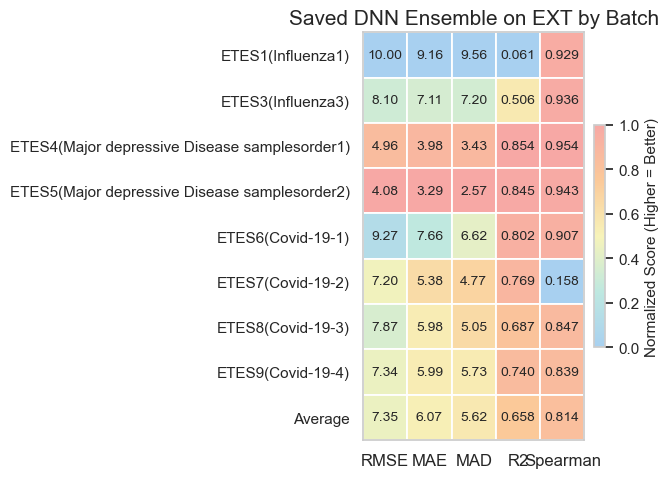

Saved figure to: EXT_batch_performance_heatmap_saved_dnn_ensemble_full.svg


In [259]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr


# ================================================================
# ================================================================
def predict_saved_ensemble(X_new_raw, loaded_ensemble, feature_cols_loaded, weight_vector):
    X_new_raw = X_new_raw.copy()
    X_new_raw = X_new_raw[feature_cols_loaded]

    model_preds = []

    for item in loaded_ensemble:
        preprocess = item["preprocess"]
        hp = item["hyperparameters"]

        X_new = preprocess.transform(X_new_raw)
        if hasattr(X_new, "toarray"):
            X_new = X_new.toarray()
        X_new = np.asarray(X_new, dtype=np.float32)

        input_dim = X_new.shape[1]

        model = load_plain_dnn_with_fallback(
            model_path=item["model_path"],
            hp=hp,
            input_dim=input_dim
        )

        pred = model(X_new, training=False).numpy().ravel()
        model_preds.append(pred)

    pred_matrix = np.column_stack(model_preds)
    ensemble_pred = pred_matrix @ np.asarray(weight_vector, dtype=float)

    return ensemble_pred, pred_matrix


# ================================================================
# ================================================================
def safe_spearman(y_true, y_pred):
    if len(y_true) < 2:
        return np.nan
    val = spearmanr(y_true, y_pred)[0]
    return float(val) if np.isfinite(val) else np.nan


def compute_metrics_with_mad(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) == 0:
        return {
            "RMSE": np.nan,
            "MAE": np.nan,
            "MAD": np.nan,
            "R2": np.nan,
            "Spearman": np.nan
        }

    abs_err = np.abs(y_true - y_pred)

    try:
        r2 = r2_score(y_true, y_pred) if len(y_true) >= 2 else np.nan
    except Exception:
        r2 = np.nan

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MAD": float(np.median(abs_err)),
        "R2": float(r2) if np.isfinite(r2) else np.nan,
        "Spearman": safe_spearman(y_true, y_pred)
    }


y_ext_pred_ens, pred_matrix_ext = predict_saved_ensemble(
    X_new_raw=X_ext_raw,
    loaded_ensemble=loaded_ensemble,
    feature_cols_loaded=feature_cols_loaded,
    weight_vector=weight_vector
)

y_ext_true = np.asarray(y_ext, dtype=float)

print("Prediction finished.")
print("pred_matrix_ext shape:", pred_matrix_ext.shape)
print("ensemble prediction shape:", y_ext_pred_ens.shape)


# ================================================================
# ================================================================
ext_result_df = test_df.copy().reset_index(drop=True)

assert len(ext_result_df) == len(y_ext_true), "Length mismatch: test_df vs y_ext"
assert len(ext_result_df) == len(y_ext_pred_ens), "Length mismatch: test_df vs ensemble predictions"

ext_result_df["y_true"] = y_ext_true
ext_result_df["y_pred"] = y_ext_pred_ens
ext_result_df["abs_error"] = np.abs(ext_result_df["y_true"] - ext_result_df["y_pred"])
ext_result_df["Batch"] = ext_result_df["Batch"].astype(str).str.strip()

print("\nEXT result preview:")
print(ext_result_df.head())


# ================================================================
# ================================================================
pred_save_name = "EXT_saved_ensemble_predictions_full.csv"
ext_result_df.to_csv(pred_save_name, index=False, encoding="utf-8-sig")
print(f"Saved prediction table to: {pred_save_name}")



metrics = ["RMSE", "MAE", "MAD", "R2", "Spearman"]

batch_metric_dict = {}
for batch, subdf in ext_result_df.groupby("Batch"):
    batch_metric_dict[batch] = compute_metrics_with_mad(
        subdf["y_true"].values,
        subdf["y_pred"].values
    )

batch_names = sorted(batch_metric_dict.keys())

raw_values = np.array([
    [batch_metric_dict[b].get(metric, np.nan) for metric in metrics]
    for b in batch_names
], dtype=float)

print("\nBatch metrics:")
for b in batch_names:
    print(b, batch_metric_dict[b])


# ================================================================
# ================================================================
scores = raw_values.copy()

for col in [0, 1, 2]:
    col_valid = raw_values[:, col]
    if np.isfinite(col_valid).any():
        col_max = np.nanmax(col_valid)
        scores[:, col] = col_max - raw_values[:, col]

col_min = np.nanmin(scores, axis=0)
col_max = np.nanmax(scores, axis=0)
norm_scores = (scores - col_min) / (col_max - col_min + 1e-12)


# ================================================================
# ================================================================
mean_scores = np.nanmean(norm_scores, axis=0)
raw_avg = np.nanmean(raw_values, axis=0)

batch_names_with_avg = batch_names + ["Average"]
norm_scores_with_avg = np.vstack([norm_scores, mean_scores])


# ================================================================
# ================================================================
custom_cmap = LinearSegmentedColormap.from_list(
    "my_cmap",
    ["#A8D0F0", "#BEE8E0", "#F7F3B9", "#FBC999", "#F7A8A5"]
)


# ================================================================
# ================================================================
fig_h = max(4.5, 0.55 * len(batch_names_with_avg))
fig, ax = plt.subplots(figsize=(6.8, fig_h))

n_rows, n_cols = norm_scores_with_avg.shape
norm = Normalize(vmin=0, vmax=1)

for i in range(n_rows):
    for j in range(n_cols):
        val = norm_scores_with_avg[i, j]
        color = custom_cmap(val) if np.isfinite(val) else (1, 1, 1, 1)

        rect = patches.Rectangle(
            (j - 0.5, i - 0.5),
            1, 1,
            facecolor=color,
            edgecolor="white",
            linewidth=1.3
        )
        ax.add_patch(rect)

        raw = raw_values[i, j] if i < n_rows - 1 else raw_avg[j]
        if np.isfinite(raw):
            text = f"{raw:.3f}" if j >= 3 else f"{raw:.2f}"
        else:
            text = "nan"

        ax.text(j, i, text, ha="center", va="center", fontsize=10)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(metrics, fontsize=12)

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(batch_names_with_avg, fontsize=11)

ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-0.5, n_rows - 0.5)
ax.invert_yaxis()

plt.title("Saved DNN Ensemble on EXT by Batch", fontsize=15)

sm = plt.cm.ScalarMappable(norm=norm, cmap=custom_cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Normalized Score (Higher = Better)", fontsize=11)

plt.tight_layout()


# ================================================================
# ================================================================
save_name = "EXT_batch_performance_heatmap_saved_dnn_ensemble_full.svg"
plt.savefig(save_name, format="svg", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_name}")

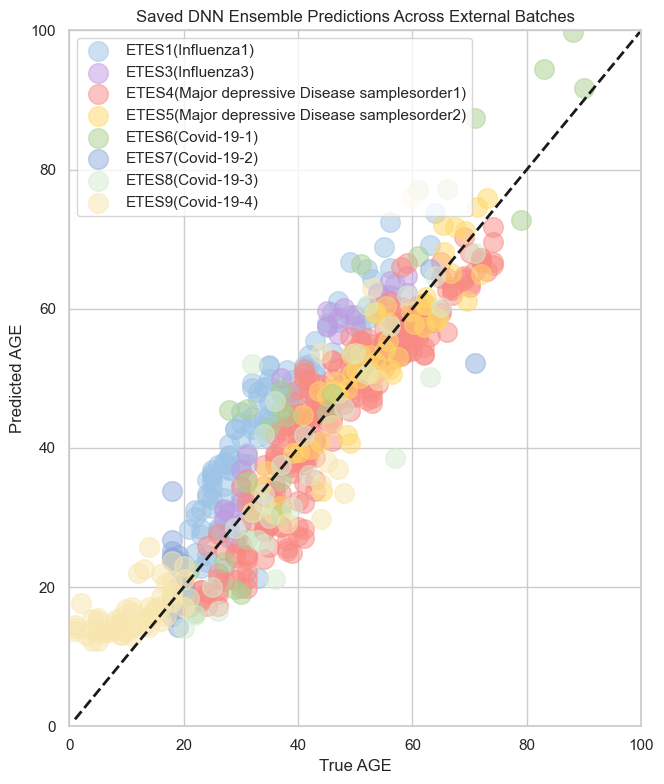

Saved figure to: external_batch_scatter_saved_dnn_ensemble.svg

===== Per-batch metrics (Saved DNN Ensemble) =====
ETES1(Influenza1) {'RMSE': 10.00417455279573, 'MAE': 9.157763029141126, 'R2': 0.06135602281423136, 'Spearman': 0.9287534017360659}
ETES3(Influenza3) {'RMSE': 8.102500331304386, 'MAE': 7.112650928249081, 'R2': 0.5056883430019252, 'Spearman': 0.9362489141544076}
ETES4(Major depressive Disease samplesorder1) {'RMSE': 4.960909987144284, 'MAE': 3.97768001222295, 'R2': 0.8539764306789788, 'Spearman': 0.9538181650574077}
ETES5(Major depressive Disease samplesorder2) {'RMSE': 4.075084332660569, 'MAE': 3.293643367062919, 'R2': 0.8448300820543666, 'Spearman': 0.94299938731592}
ETES6(Covid-19-1) {'RMSE': 9.27125492840189, 'MAE': 7.663366754416242, 'R2': 0.8015102981020571, 'Spearman': 0.906624706620254}
ETES7(Covid-19-2) {'RMSE': 7.20131174654089, 'MAE': 5.380071714596244, 'R2': 0.7688529780177885, 'Spearman': 0.157959700735758}
ETES8(Covid-19-3) {'RMSE': 7.865509688015534, 'MAE': 5.

In [261]:
# ==============================================================
#   Scatter by Batch (Saved DNN Ensemble) - styled like your example
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr

# --------------------------------------------------------------
# 0. Basic checks
# Required:
#   ext_result_df with columns: Batch, y_true, y_pred
# --------------------------------------------------------------
required_cols = ["Batch", "y_true", "y_pred"]
for c in required_cols:
    assert c in ext_result_df.columns, f"{c} not found in ext_result_df"

plot_df = ext_result_df.copy()
plot_df["Batch"] = plot_df["Batch"].astype(str).str.strip()

# batch list in sorted order
batch_list = sorted(plot_df["Batch"].unique())

# fixed color palette like your example
colors = ["#9DC3E6", "#C198E0", "#F98A83", "#FFD966", "#A9D18E","#8FAADC","#D5ECD1","#F8E6AF","#F7A8A5"]

batch_metrics_summary = {}


# --------------------------------------------------------------
# 1. Metric function
# --------------------------------------------------------------
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    if len(y_true) == 0:
        return {
            "RMSE": np.nan,
            "MAE": np.nan,
            "R2": np.nan,
            "Spearman": np.nan
        }

    try:
        r2 = r2_score(y_true, y_pred) if len(y_true) >= 2 else np.nan
    except Exception:
        r2 = np.nan

    try:
        spr = spearmanr(y_true, y_pred)[0] if len(y_true) >= 2 else np.nan
        spr = float(spr) if np.isfinite(spr) else np.nan
    except Exception:
        spr = np.nan

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2) if np.isfinite(r2) else np.nan,
        "Spearman": spr
    }


# --------------------------------------------------------------
# 2. Scatter plot
# --------------------------------------------------------------
plt.figure(figsize=(8, 8))

for i, batch in enumerate(batch_list):
    subdf = plot_df[plot_df["Batch"] == batch].copy()

    y_sub = subdf["y_true"].astype(float).values
    preds = subdf["y_pred"].astype(float).values

    metrics_sub = calc_metrics(y_sub, preds)
    batch_metrics_summary[batch] = metrics_sub

    plt.scatter(
        y_sub, preds,
        s=200,
        alpha=0.5,
        color=colors[i % len(colors)],
        label=batch
    )

# y=x reference line
all_y = plot_df["y_true"].astype(float).values
all_pred = plot_df["y_pred"].astype(float).values

mn = float(np.nanmin([np.nanmin(all_y), np.nanmin(all_pred)]))
mx = float(np.nanmax([np.nanmax(all_y), np.nanmax(all_pred)]))

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.plot([mn, mx], [mn, mx], "k--", linewidth=2)

plt.xlabel("True AGE")
plt.ylabel("Predicted AGE")
plt.title("Saved DNN Ensemble Predictions Across External Batches")
plt.grid(True)
plt.legend()

plt.tight_layout(rect=[0, 0, 0.85, 1])

save_name = "external_batch_scatter_saved_dnn_ensemble.svg"
plt.savefig(save_name, format="svg", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_name}")


# --------------------------------------------------------------
# 3. Print per-batch metrics
# --------------------------------------------------------------
print("\n===== Per-batch metrics (Saved DNN Ensemble) =====")
for b in batch_list:
    if b in batch_metrics_summary:
        print(b, batch_metrics_summary[b])

Saved to: INT_saved_ensemble_predictions.csv
Saved to: INT_EXT_saved_ensemble_predictions.csv


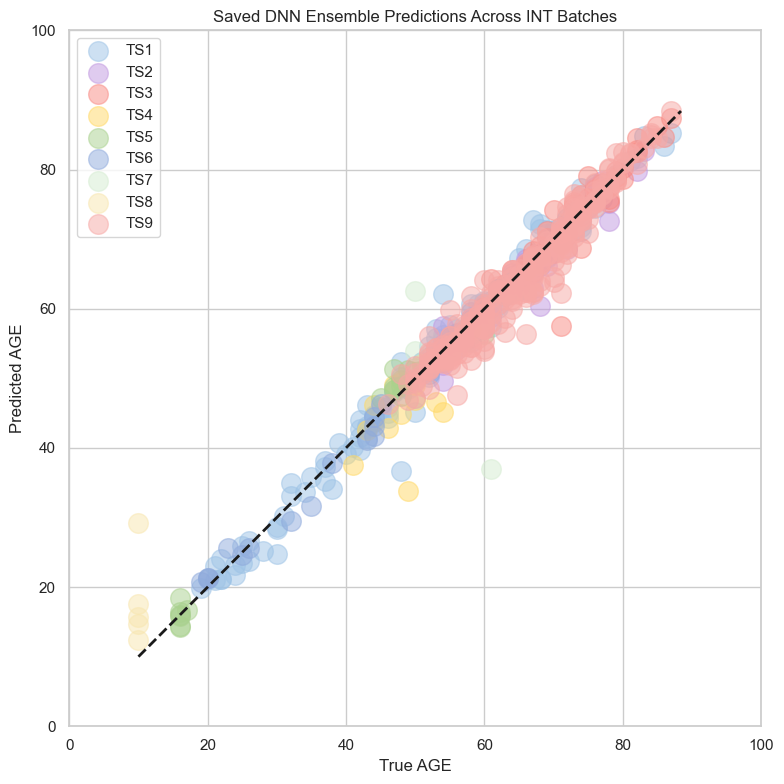

Saved figure to: INT_scatter_saved_dnn_ensemble.svg

===== Per-batch metrics: Saved DNN Ensemble Predictions Across INT Batches =====
TS1 {'RMSE': 2.0384221137052974, 'MAE': 1.4270764387170378, 'MAD': 1.0388795761268277, 'R2': 0.9833438249457283, 'Spearman': 0.9895279707294055}
TS2 {'RMSE': 2.1769707048890354, 'MAE': 1.5762520590908529, 'MAD': 1.1831433895872934, 'R2': 0.9290032800327019, 'Spearman': 0.9622023457542614}
TS3 {'RMSE': 2.441895196937235, 'MAE': 1.4582779075038832, 'MAD': 1.0126679423214782, 'R2': 0.8560336262683264, 'Spearman': 0.9453480737950563}
TS4 {'RMSE': 5.5645769990330285, 'MAE': 3.9385848209941536, 'MAD': 3.114192240103506, 'R2': -1.313440938598716, 'Spearman': 0.46005684211656367}
TS5 {'RMSE': 1.887123091609308, 'MAE': 1.5015380455469374, 'MAD': 1.5233271014636127, 'R2': 0.9864948479654627, 'Spearman': 0.9094323454936267}
TS6 {'RMSE': 1.5611434700929039, 'MAE': 1.3006816003394635, 'MAD': 1.2695963540509752, 'R2': 0.9890868106265633, 'Spearman': 0.9923301203560673

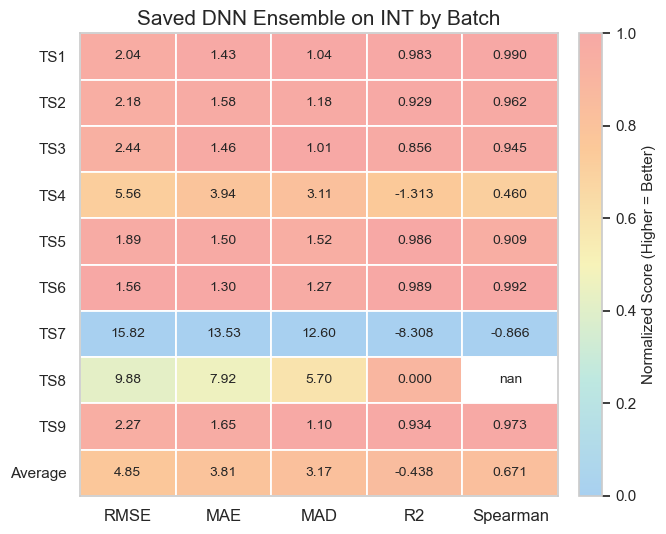

Saved figure to: INT_heatmap_saved_dnn_ensemble.svg


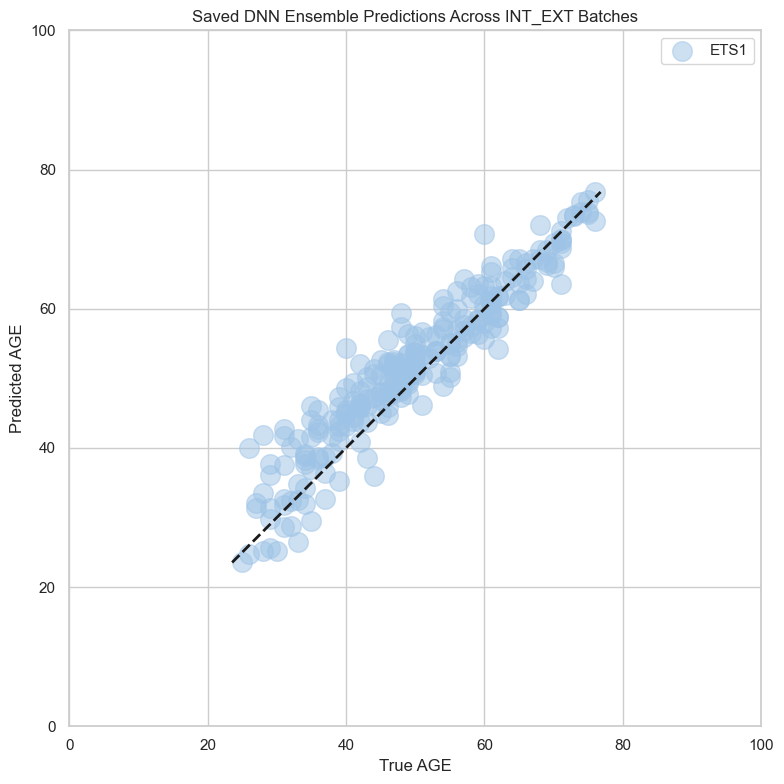

Saved figure to: INT_EXT_scatter_saved_dnn_ensemble.svg

===== Per-batch metrics: Saved DNN Ensemble Predictions Across INT_EXT Batches =====
ETS1 {'RMSE': 4.527139515330163, 'MAE': 3.4933264048723167, 'MAD': 3.0819946442133386, 'R2': 0.8704381994164583, 'Spearman': 0.9539799601048736}


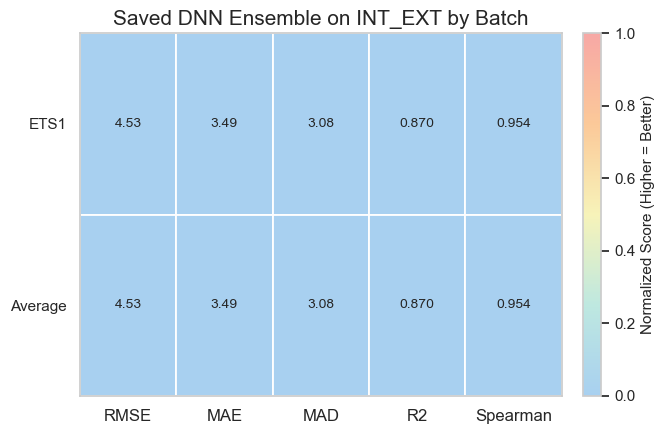

Saved figure to: INT_EXT_heatmap_saved_dnn_ensemble.svg


In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr


# ==============================================================
# 1. ensemble prediction function
# ==============================================================
def predict_saved_ensemble(X_new_raw, loaded_ensemble, feature_cols_loaded, weight_vector):
    X_new_raw = X_new_raw.copy()
    X_new_raw = X_new_raw[feature_cols_loaded]

    model_preds = []

    for item in loaded_ensemble:
        preprocess = item["preprocess"]
        hp = item["hyperparameters"]

        X_new = preprocess.transform(X_new_raw)
        if hasattr(X_new, "toarray"):
            X_new = X_new.toarray()
        X_new = np.asarray(X_new, dtype=np.float32)

        input_dim = X_new.shape[1]

        model = load_plain_dnn_with_fallback(
            model_path=item["model_path"],
            hp=hp,
            input_dim=input_dim
        )

        pred = model(X_new, training=False).numpy().ravel()
        model_preds.append(pred)

    pred_matrix = np.column_stack(model_preds)
    ensemble_pred = pred_matrix @ np.asarray(weight_vector, dtype=float)
    return ensemble_pred, pred_matrix


# ==============================================================
# 2. metric helpers
# ==============================================================
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    if len(y_true) == 0:
        return {
            "RMSE": np.nan,
            "MAE": np.nan,
            "MAD": np.nan,
            "R2": np.nan,
            "Spearman": np.nan
        }

    abs_err = np.abs(y_true - y_pred)

    try:
        r2 = r2_score(y_true, y_pred) if len(y_true) >= 2 else np.nan
    except Exception:
        r2 = np.nan

    try:
        spr = spearmanr(y_true, y_pred)[0] if len(y_true) >= 2 else np.nan
        spr = float(spr) if np.isfinite(spr) else np.nan
    except Exception:
        spr = np.nan

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MAD": float(np.median(abs_err)),
        "R2": float(r2) if np.isfinite(r2) else np.nan,
        "Spearman": spr
    }


def plot_scatter_by_batch(result_df, title, save_name):
    colors = ["#9DC3E6", "#C198E0", "#F98A83", "#FFD966", "#A9D18E","#8FAADC","#D5ECD1","#F8E6AF","#F7A8A5"]
    batch_list = sorted(result_df["Batch"].astype(str).str.strip().unique())
    batch_metrics_summary = {}

    plt.figure(figsize=(8, 8))

    for i, batch in enumerate(batch_list):
        subdf = result_df[result_df["Batch"].astype(str).str.strip() == batch].copy()

        y_sub = subdf["y_true"].astype(float).values
        preds = subdf["y_pred"].astype(float).values

        metrics_sub = calc_metrics(y_sub, preds)
        batch_metrics_summary[batch] = metrics_sub

        plt.scatter(
            y_sub, preds,
            s=200,
            alpha=0.5,
            color=colors[i % len(colors)],
            label=batch
        )

    all_y = result_df["y_true"].astype(float).values
    all_pred = result_df["y_pred"].astype(float).values

    mn = float(np.nanmin([np.nanmin(all_y), np.nanmin(all_pred)]))
    mx = float(np.nanmax([np.nanmax(all_y), np.nanmax(all_pred)]))

    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=2)

    plt.xlabel("True AGE")
    plt.ylabel("Predicted AGE")
    plt.title(title)
    plt.grid(True)
    plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.savefig(save_name, format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure to: {save_name}")
    print(f"\n===== Per-batch metrics: {title} =====")
    for b in batch_list:
        print(b, batch_metrics_summary[b])

    return batch_metrics_summary


def plot_heatmap_from_result_df(result_df, title, save_name):
    metrics = ["RMSE", "MAE", "MAD", "R2", "Spearman"]

    batch_metric_dict = {}
    for batch, subdf in result_df.groupby("Batch"):
        batch_metric_dict[batch] = calc_metrics(
            subdf["y_true"].values,
            subdf["y_pred"].values
        )

    batch_names = sorted(batch_metric_dict.keys())

    raw_values = np.array([
        [batch_metric_dict[b].get(metric, np.nan) for metric in metrics]
        for b in batch_names
    ], dtype=float)

    scores = raw_values.copy()
    for col in [0, 1, 2]:
        col_valid = raw_values[:, col]
        if np.isfinite(col_valid).any():
            col_max = np.nanmax(col_valid)
            scores[:, col] = col_max - raw_values[:, col]

    col_min = np.nanmin(scores, axis=0)
    col_max = np.nanmax(scores, axis=0)
    norm_scores = (scores - col_min) / (col_max - col_min + 1e-12)

    mean_scores = np.nanmean(norm_scores, axis=0)
    raw_avg = np.nanmean(raw_values, axis=0)

    batch_names_with_avg = batch_names + ["Average"]
    norm_scores_with_avg = np.vstack([norm_scores, mean_scores])

    custom_cmap = LinearSegmentedColormap.from_list(
        "my_cmap",
        ["#A8D0F0", "#BEE8E0", "#F7F3B9", "#FBC999", "#F7A8A5"]
    )

    fig_h = max(4.5, 0.55 * len(batch_names_with_avg))
    fig, ax = plt.subplots(figsize=(6.8, fig_h))

    n_rows, n_cols = norm_scores_with_avg.shape
    norm = Normalize(vmin=0, vmax=1)

    for i in range(n_rows):
        for j in range(n_cols):
            val = norm_scores_with_avg[i, j]
            color = custom_cmap(val) if np.isfinite(val) else (1, 1, 1, 1)

            rect = patches.Rectangle(
                (j - 0.5, i - 0.5),
                1, 1,
                facecolor=color,
                edgecolor="white",
                linewidth=1.3
            )
            ax.add_patch(rect)

            raw = raw_values[i, j] if i < n_rows - 1 else raw_avg[j]
            if np.isfinite(raw):
                text = f"{raw:.3f}" if j >= 3 else f"{raw:.2f}"
            else:
                text = "nan"

            ax.text(j, i, text, ha="center", va="center", fontsize=10)

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(metrics, fontsize=12)

    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(batch_names_with_avg, fontsize=11)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)
    ax.invert_yaxis()

    plt.title(title, fontsize=15)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=custom_cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Normalized Score (Higher = Better)", fontsize=11)

    plt.tight_layout()
    plt.savefig(save_name, format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure to: {save_name}")


# ==============================================================
# 3. predict INT
# ==============================================================
y_int_pred_ens, pred_matrix_int = predict_saved_ensemble(
    X_new_raw=X_int_raw,
    loaded_ensemble=loaded_ensemble,
    feature_cols_loaded=feature_cols_loaded,
    weight_vector=weight_vector
)

int_meta_df = train_pool_df.loc[X_int_raw.index].copy().reset_index(drop=True)
int_result_df = int_meta_df.copy()
int_result_df["Batch"] = int_result_df["Batch"].astype(str).str.strip()
int_result_df["y_true"] = np.asarray(y_int, dtype=float)
int_result_df["y_pred"] = np.asarray(y_int_pred_ens, dtype=float)
int_result_df["abs_error"] = np.abs(int_result_df["y_true"] - int_result_df["y_pred"])

int_result_df.to_csv("INT_saved_ensemble_predictions.csv", index=False, encoding="utf-8-sig")
print("Saved to: INT_saved_ensemble_predictions.csv")


# ==============================================================
# 4. predict INT_EXT
# ==============================================================
y_int_ext_pred_ens, pred_matrix_int_ext = predict_saved_ensemble(
    X_new_raw=X_int_ext_raw,
    loaded_ensemble=loaded_ensemble,
    feature_cols_loaded=feature_cols_loaded,
    weight_vector=weight_vector
)

int_ext_result_df = int_ext_df.copy().reset_index(drop=True)
int_ext_result_df["Batch"] = int_ext_result_df["Batch"].astype(str).str.strip()
int_ext_result_df["y_true"] = np.asarray(y_int_ext, dtype=float)
int_ext_result_df["y_pred"] = np.asarray(y_int_ext_pred_ens, dtype=float)
int_ext_result_df["abs_error"] = np.abs(int_ext_result_df["y_true"] - int_ext_result_df["y_pred"])

int_ext_result_df.to_csv("INT_EXT_saved_ensemble_predictions.csv", index=False, encoding="utf-8-sig")
print("Saved to: INT_EXT_saved_ensemble_predictions.csv")


# ==============================================================
# 5. plot INT scatter + heatmap
# ==============================================================
plot_scatter_by_batch(
    result_df=int_result_df,
    title="Saved DNN Ensemble Predictions Across INT Batches",
    save_name="INT_scatter_saved_dnn_ensemble.svg"
)

plot_heatmap_from_result_df(
    result_df=int_result_df,
    title="Saved DNN Ensemble on INT by Batch",
    save_name="INT_heatmap_saved_dnn_ensemble.svg"
)


# ==============================================================
# 6. plot INT_EXT scatter + heatmap
# ==============================================================
plot_scatter_by_batch(
    result_df=int_ext_result_df,
    title="Saved DNN Ensemble Predictions Across INT_EXT Batches",
    save_name="INT_EXT_scatter_saved_dnn_ensemble.svg"
)

plot_heatmap_from_result_df(
    result_df=int_ext_result_df,
    title="Saved DNN Ensemble on INT_EXT by Batch",
    save_name="INT_EXT_heatmap_saved_dnn_ensemble.svg"
)

COV-related batches found:
['ETES6(Covid-19-1)', 'ETES7(Covid-19-2)', 'ETES8(Covid-19-3)', 'ETES9(Covid-19-4)']
Number of samples: 147


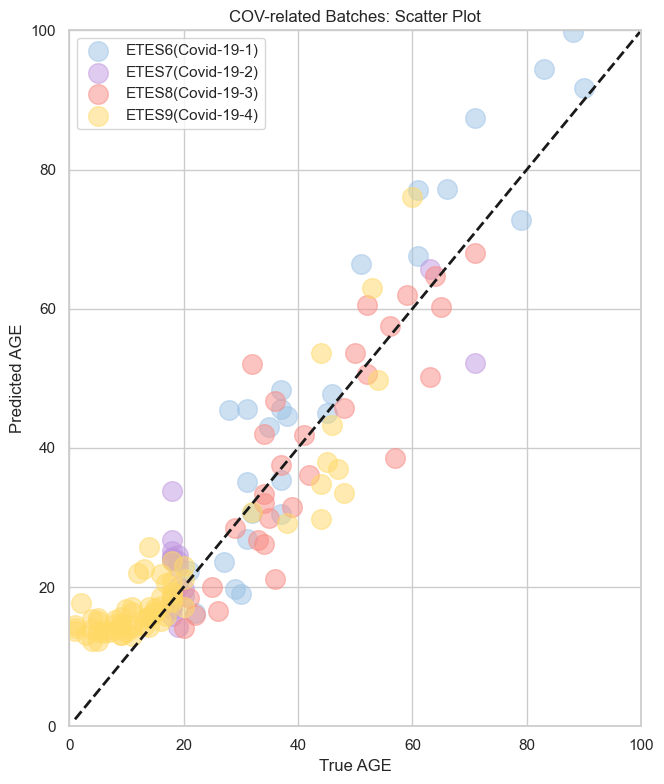

Saved figure to: COV_batches_scatter.svg

===== Per-batch metrics (COV batches) =====
ETES6(Covid-19-1) {'RMSE': 9.27125492840189, 'MAE': 7.663366754416242, 'MAD': 6.619337243467022, 'R2': 0.8015102981020571, 'Spearman': 0.906624706620254}
ETES7(Covid-19-2) {'RMSE': 7.20131174654089, 'MAE': 5.380071714596244, 'MAD': 4.7666864775484825, 'R2': 0.7688529780177885, 'Spearman': 0.157959700735758}
ETES8(Covid-19-3) {'RMSE': 7.865509688015534, 'MAE': 5.980309324743167, 'MAD': 5.047290274206691, 'R2': 0.6870894375830213, 'Spearman': 0.8465144563057816}
ETES9(Covid-19-4) {'RMSE': 7.340775461339395, 'MAE': 5.989943116633846, 'MAD': 5.7292215197488225, 'R2': 0.7395182093910599, 'Spearman': 0.8391847084183381}


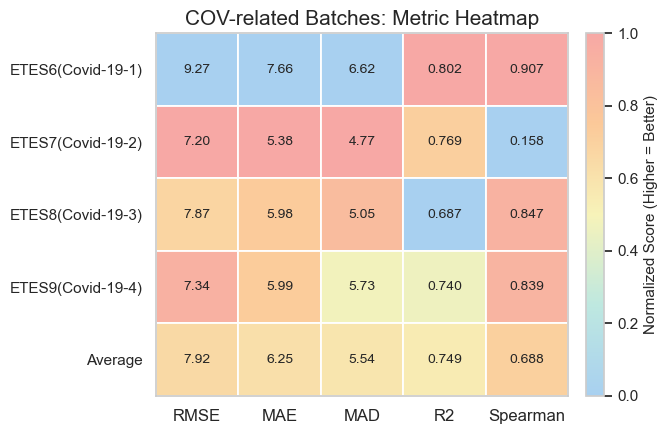

Saved figure to: COV_batches_metric_heatmap.svg


In [265]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr

# ==============================================================
# 0) 选择你当前已有的结果表
#    可选：
#    result_df = ext_result_df
#    result_df = int_ext_result_df
#    result_df = int_result_df
# ==============================================================
result_df = ext_result_df.copy()

# 检查必要列
required_cols = ["Batch", "y_true", "y_pred"]
for c in required_cols:
    assert c in result_df.columns, f"{c} not found in result_df"

result_df["Batch"] = result_df["Batch"].astype(str).str.strip()

# ==============================================================
# 1) 提取 Batch 名中包含 COV 的批次
# ==============================================================
cov_df = result_df[result_df["Batch"].str.contains("COV", case=False, na=False)].copy()

if len(cov_df) == 0:
    raise ValueError("No batches containing 'COV' were found in the current result_df.")

print("COV-related batches found:")
print(sorted(cov_df["Batch"].unique()))
print("Number of samples:", len(cov_df))


# ==============================================================
# 2) 指标函数
# ==============================================================
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    if len(y_true) == 0:
        return {
            "RMSE": np.nan,
            "MAE": np.nan,
            "MAD": np.nan,
            "R2": np.nan,
            "Spearman": np.nan
        }

    abs_err = np.abs(y_true - y_pred)

    try:
        r2 = r2_score(y_true, y_pred) if len(y_true) >= 2 else np.nan
    except Exception:
        r2 = np.nan

    try:
        spr = spearmanr(y_true, y_pred)[0] if len(y_true) >= 2 else np.nan
        spr = float(spr) if np.isfinite(spr) else np.nan
    except Exception:
        spr = np.nan

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MAD": float(np.median(abs_err)),
        "R2": float(r2) if np.isfinite(r2) else np.nan,
        "Spearman": spr
    }


# ==============================================================
# 3) 绘制 COV 批次散点图
# ==============================================================
colors = ["#9DC3E6", "#C198E0", "#F98A83", "#FFD966", "#A9D18E", "#70AD47", "#5B9BD5"]
batch_list = sorted(cov_df["Batch"].unique())
batch_metrics_summary = {}

plt.figure(figsize=(8, 8))

for i, batch in enumerate(batch_list):
    subdf = cov_df[cov_df["Batch"] == batch].copy()

    y_sub = subdf["y_true"].astype(float).values
    preds = subdf["y_pred"].astype(float).values

    metrics_sub = calc_metrics(y_sub, preds)
    batch_metrics_summary[batch] = metrics_sub

    plt.scatter(
        y_sub, preds,
        s=200,
        alpha=0.5,
        color=colors[i % len(colors)],
        label=batch
    )

all_y = cov_df["y_true"].astype(float).values
all_pred = cov_df["y_pred"].astype(float).values

mn = float(np.nanmin([np.nanmin(all_y), np.nanmin(all_pred)]))
mx = float(np.nanmax([np.nanmax(all_y), np.nanmax(all_pred)]))

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.plot([mn, mx], [mn, mx], "k--", linewidth=2)

plt.xlabel("True AGE")
plt.ylabel("Predicted AGE")
plt.title("COV-related Batches: Scatter Plot")
plt.grid(True)
plt.legend()

plt.tight_layout(rect=[0, 0, 0.85, 1])

scatter_save_name = "COV_batches_scatter.svg"
plt.savefig(scatter_save_name, format="svg", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {scatter_save_name}")


# ==============================================================
# 4) 打印每个 COV 批次的指标
# ==============================================================
print("\n===== Per-batch metrics (COV batches) =====")
for b in batch_list:
    print(b, batch_metrics_summary[b])


# ==============================================================
# 5) 计算热力图数据
# ==============================================================
metrics = ["RMSE", "MAE", "MAD", "R2", "Spearman"]

raw_values = np.array([
    [batch_metrics_summary[b].get(metric, np.nan) for metric in metrics]
    for b in batch_list
], dtype=float)

scores = raw_values.copy()

# RMSE / MAE / MAD 越小越好，所以反转
for col in [0, 1, 2]:
    col_valid = raw_values[:, col]
    if np.isfinite(col_valid).any():
        col_max = np.nanmax(col_valid)
        scores[:, col] = col_max - raw_values[:, col]

col_min = np.nanmin(scores, axis=0)
col_max = np.nanmax(scores, axis=0)
norm_scores = (scores - col_min) / (col_max - col_min + 1e-12)

# 平均行
mean_scores = np.nanmean(norm_scores, axis=0)
raw_avg = np.nanmean(raw_values, axis=0)

batch_names_with_avg = batch_list + ["Average"]
norm_scores_with_avg = np.vstack([norm_scores, mean_scores])


# ==============================================================
# 6) 绘制热力图
# ==============================================================
custom_cmap = LinearSegmentedColormap.from_list(
    "my_cmap",
    ["#A8D0F0", "#BEE8E0", "#F7F3B9", "#FBC999", "#F7A8A5"]
)

fig_h = max(4.5, 0.55 * len(batch_names_with_avg))
fig, ax = plt.subplots(figsize=(6.8, fig_h))

n_rows, n_cols = norm_scores_with_avg.shape
norm = Normalize(vmin=0, vmax=1)

for i in range(n_rows):
    for j in range(n_cols):
        val = norm_scores_with_avg[i, j]
        color = custom_cmap(val) if np.isfinite(val) else (1, 1, 1, 1)

        rect = patches.Rectangle(
            (j - 0.5, i - 0.5),
            1, 1,
            facecolor=color,
            edgecolor="white",
            linewidth=1.3
        )
        ax.add_patch(rect)

        raw = raw_values[i, j] if i < n_rows - 1 else raw_avg[j]
        if np.isfinite(raw):
            text = f"{raw:.3f}" if j >= 3 else f"{raw:.2f}"
        else:
            text = "nan"

        ax.text(j, i, text, ha="center", va="center", fontsize=10)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(metrics, fontsize=12)

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(batch_names_with_avg, fontsize=11)

ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-0.5, n_rows - 0.5)
ax.invert_yaxis()

plt.title("COV-related Batches: Metric Heatmap", fontsize=15)

sm = plt.cm.ScalarMappable(norm=norm, cmap=custom_cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Normalized Score (Higher = Better)", fontsize=11)

plt.tight_layout()

heatmap_save_name = "COV_batches_metric_heatmap.svg"
plt.savefig(heatmap_save_name, format="svg", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {heatmap_save_name}")

Selected batches:
['ETES6(Covid-19-1)', 'ETES7(Covid-19-2)', 'ETES8(Covid-19-3)', 'ETES9(Covid-19-4)']
Sample number: 616
DIS_HEA_2
COVID    469
HEA      147
Name: count, dtype: int64
(616, 15)


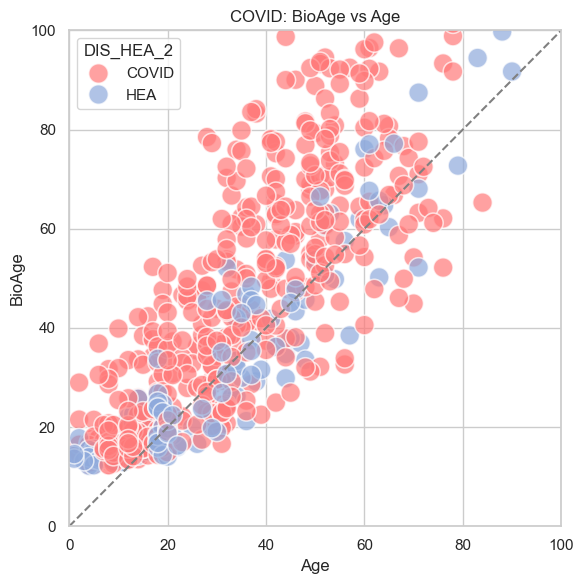

COVID_scatter_saved_ensemble.svg
          MAE    RMSE     R2  Spearman     MAD    N
Group                                              
COVID  14.725  19.643 -0.022     0.842  11.209  469
HEA     6.228   7.833  0.847     0.913   5.750  147


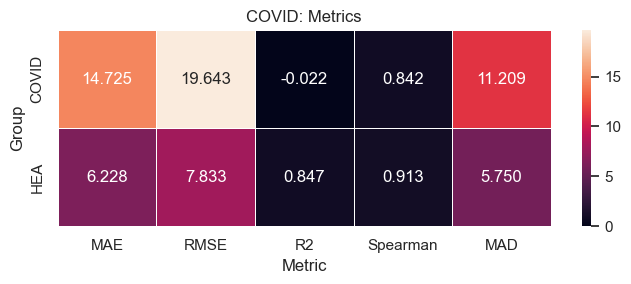

COVID_metrics_heatmap_saved_ensemble.svg
COVID_saved_ensemble_predictions.csv


In [270]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

# ==============================================================
# Parameters
# ==============================================================

TARGET_BATCHES = [
    "ETES6(Covid-19-1)",
    "ETES7(Covid-19-2)",
    "ETES8(Covid-19-3)",
    "ETES9(Covid-19-4)",
]

DISEASE_LABEL = "COVID"
SAVE_PREFIX = "COVID"

# ==============================================================
# Prediction
# ==============================================================

def predict_saved_ensemble(
    X_new_raw,
    loaded_ensemble,
    feature_cols_loaded,
    weight_vector,
):
    X_new_raw = X_new_raw.copy()
    X_new_raw = X_new_raw[feature_cols_loaded]

    preds = []

    for item in loaded_ensemble:

        preprocess = item["preprocess"]
        hp = item["hyperparameters"]

        X_new = preprocess.transform(X_new_raw)

        if hasattr(X_new, "toarray"):
            X_new = X_new.toarray()

        X_new = np.asarray(X_new, dtype=np.float32)

        model = load_plain_dnn_with_fallback(
            model_path=item["model_path"],
            hp=hp,
            input_dim=X_new.shape[1],
        )

        pred = model(
            X_new,
            training=False,
        ).numpy().ravel()

        preds.append(pred)

    pred_matrix = np.column_stack(preds)

    ensemble_pred = (
        pred_matrix
        @ np.asarray(weight_vector, dtype=float)
    )

    return ensemble_pred, pred_matrix


# ==============================================================
# Metrics
# ==============================================================

def calc_metrics(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    if len(y_true) == 0:
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "Spearman": np.nan,
            "MAD": np.nan,
            "N": 0,
        }

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mad = np.median(np.abs(y_pred - y_true))

    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = np.nan

    try:
        sp = spearmanr(
            y_true,
            y_pred,
            nan_policy="omit",
        ).correlation
    except Exception:
        sp = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Spearman": sp,
        "MAD": mad,
        "N": len(y_true),
    }


# ==============================================================
# Select batches
# ==============================================================

df_target = dat.copy()

df_target["Batch"] = (
    df_target["Batch"]
    .astype(str)
    .str.strip()
)

df_target["DIS_HEA"] = (
    df_target["DIS_HEA"]
    .astype(str)
)

target_set = {
    x.strip()
    for x in TARGET_BATCHES
}

df_target = df_target[
    df_target["Batch"].isin(target_set)
].copy()

if df_target.empty:
    raise ValueError("No samples selected.")

df_target["DIS_HEA_2"] = df_target["DIS_HEA"].apply(
    lambda x:
    "HEA"
    if "HEA" in x.upper()
    else DISEASE_LABEL
)

print("Selected batches:")
print(sorted(df_target["Batch"].unique()))
print(f"Sample number: {len(df_target)}")
print(df_target["DIS_HEA_2"].value_counts())


# ==============================================================
# Prediction
# ==============================================================

X_target_raw = df_target[
    feature_cols_loaded
].copy()

y_target_pred, pred_matrix = predict_saved_ensemble(
    X_new_raw=X_target_raw,
    loaded_ensemble=loaded_ensemble,
    feature_cols_loaded=feature_cols_loaded,
    weight_vector=weight_vector,
)

df_target["AGE_pred_weighted"] = y_target_pred
df_target["Error"] = (
    df_target["AGE_pred_weighted"]
    - df_target["AGE"]
)

print(pred_matrix.shape)


# ==============================================================
# Scatter
# ==============================================================

palette = {
    DISEASE_LABEL: "#FF7979",
    "HEA": "#8FAADC",
}

fig, ax = plt.subplots(figsize=(6, 6))

sns.scatterplot(
    data=df_target,
    x="AGE",
    y="AGE_pred_weighted",
    hue="DIS_HEA_2",
    hue_order=[DISEASE_LABEL, "HEA"],
    palette=palette,
    s=200,
    alpha=0.7,
    ax=ax,
)

ax.plot(
    [0, 100],
    [0, 100],
    "--",
    color="gray",
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.set_xlabel("Age")
ax.set_ylabel("BioAge")

ax.set_title(
    f"{DISEASE_LABEL}: BioAge vs Age"
)

plt.tight_layout()

scatter_name = (
    f"{SAVE_PREFIX}_scatter_saved_ensemble.svg"
)

plt.savefig(
    scatter_name,
    format="svg",
    bbox_inches="tight",
)

plt.show()
plt.close()

print(scatter_name)


# ==============================================================
# Metrics
# ==============================================================

rows = []

for grp, df_g in df_target.groupby("DIS_HEA_2"):

    m = calc_metrics(
        df_g["AGE"],
        df_g["AGE_pred_weighted"],
    )

    m["Group"] = grp

    rows.append(m)

metrics_df = (
    pd.DataFrame(rows)
    .set_index("Group")
)

print(metrics_df.round(3))


# ==============================================================
# Heatmap
# ==============================================================

heat_df = metrics_df[
    [
        "MAE",
        "RMSE",
        "R2",
        "Spearman",
        "MAD",
    ]
]

fig, ax = plt.subplots(
    figsize=(7, 3)
)

sns.heatmap(
    heat_df,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    ax=ax,
)

ax.set_xlabel("Metric")
ax.set_ylabel("Group")

ax.set_title(
    f"{DISEASE_LABEL}: Metrics"
)

plt.tight_layout()

heat_name = (
    f"{SAVE_PREFIX}_metrics_heatmap_saved_ensemble.svg"
)

plt.savefig(
    heat_name,
    format="svg",
    bbox_inches="tight",
)

plt.show()
plt.close()

print(heat_name)


# ==============================================================
# Save
# ==============================================================

csv_name = (
    f"{SAVE_PREFIX}_saved_ensemble_predictions.csv"
)

df_target.to_csv(
    csv_name,
    index=False,
    encoding="utf-8-sig",
)

print(csv_name)

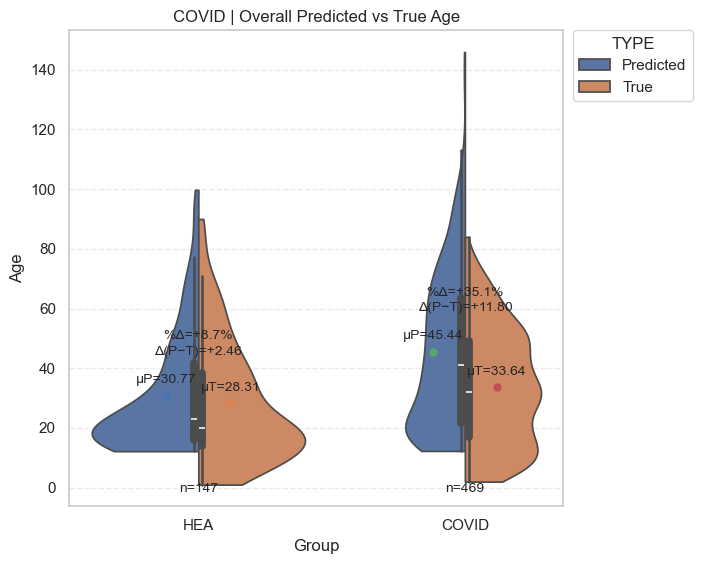

COVID_violin_overall.svg


In [271]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


# ==============================================================
# Check dataframe
# ==============================================================

required_cols = [
    "DIS_HEA_2",
    "AGE",
    "AGE_pred_weighted",
]

for col in required_cols:
    assert col in df_target.columns, f"{col} not found."


# ==============================================================
# Violin plot
# ==============================================================

def plot_violin_overall(
    df,
    disease_label,
    save_path,
):

    long_df = pd.concat(
        [

            df[
                [
                    "DIS_HEA_2",
                    "AGE_pred_weighted",
                ]
            ]
            .rename(
                columns={
                    "AGE_pred_weighted": "AGE"
                }
            )
            .assign(
                TYPE="Predicted"
            ),

            df[
                [
                    "DIS_HEA_2",
                    "AGE",
                ]
            ]
            .assign(
                TYPE="True"
            ),

        ],
        ignore_index=True,
    )

    long_df["TYPE"] = pd.Categorical(
        long_df["TYPE"],
        categories=[
            "Predicted",
            "True",
        ],
        ordered=True,
    )

    order_use = [
        "HEA",
        disease_label,
    ]

    fig, ax = plt.subplots(
        figsize=(7.2, 5.8)
    )

    sns.violinplot(
        data=long_df,
        x="DIS_HEA_2",
        y="AGE",
        hue="TYPE",
        hue_order=[
            "Predicted",
            "True",
        ],
        order=order_use,
        split=True,
        inner="box",
        cut=0,
        ax=ax,
    )

    mean_table = (
        long_df
        .groupby(
            [
                "DIS_HEA_2",
                "TYPE",
            ]
        )["AGE"]
        .mean()
        .unstack("TYPE")
        .reindex(order_use)
    )

    n_table = (
        df["DIS_HEA_2"]
        .value_counts()
        .reindex(order_use)
        .fillna(0)
        .astype(int)
    )

    x_off = 0.12

    ymin, ymax = ax.get_ylim()

    y_pad = 0.02 * (
        ymax - ymin
    )

    for i, grp in enumerate(order_use):

        if grp not in mean_table.index:
            continue

        pred_mu = (
            mean_table.loc[
                grp,
                "Predicted",
            ]
            if "Predicted" in mean_table.columns
            else np.nan
        )

        true_mu = (
            mean_table.loc[
                grp,
                "True",
            ]
            if "True" in mean_table.columns
            else np.nan
        )

        if pd.notna(pred_mu):

            ax.scatter(
                i - x_off,
                pred_mu,
                s=25,
                zorder=6,
            )

            ax.text(
                i - x_off,
                pred_mu + y_pad,
                f"μP={pred_mu:.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

        if pd.notna(true_mu):

            ax.scatter(
                i + x_off,
                true_mu,
                s=25,
                zorder=6,
            )

            ax.text(
                i + x_off,
                true_mu + y_pad,
                f"μT={true_mu:.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

        if (
            pd.notna(pred_mu)
            and
            pd.notna(true_mu)
        ):

            delta = (
                pred_mu
                - true_mu
            )

            pct = (
                delta
                / true_mu
                * 100
            ) if true_mu != 0 else np.nan

            y_top = (
                max(
                    pred_mu,
                    true_mu,
                )
                + 4 * y_pad
            )

            ax.text(
                i,
                y_top,
                f"Δ(P−T)={delta:+.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

            ax.text(
                i,
                y_top + 1.6 * y_pad,
                (
                    f"%Δ={pct:+.1f}%"
                    if np.isfinite(pct)
                    else "%Δ=nan"
                ),
                ha="center",
                va="bottom",
                fontsize=10,
            )

        ax.text(
            i,
            ymin + 1.2 * y_pad,
            f"n={n_table.loc[grp]}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    ax.set_title(
        f"{disease_label} | Overall Predicted vs True Age"
    )

    ax.set_xlabel("Group")

    ax.set_ylabel("Age")

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4,
    )

    ax.legend(
        title="TYPE",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
    )

    plt.tight_layout()

    plt.savefig(
        save_path,
        format="svg",
        bbox_inches="tight",
    )

    plt.show()

    plt.close()

    print(save_path)


# ==============================================================
# Run
# ==============================================================

plot_violin_overall(
    df=df_target,
    disease_label=DISEASE_LABEL,
    save_path=f"{SAVE_PREFIX}_violin_overall.svg",
)

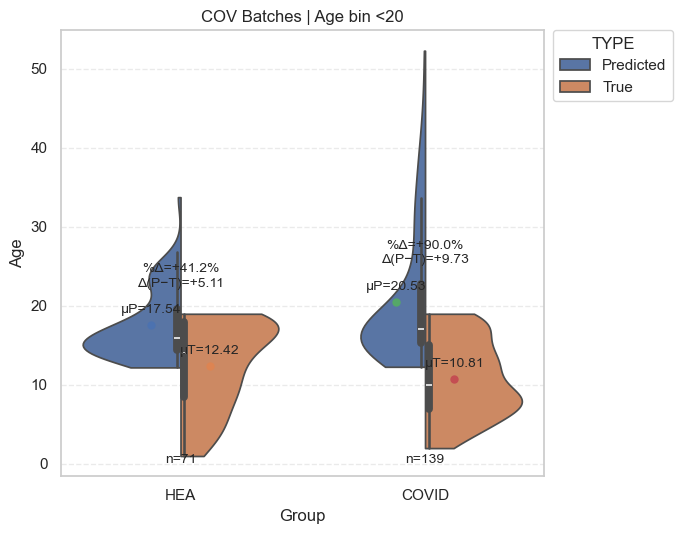

Saved: COV_violin_agebin_lt20.svg


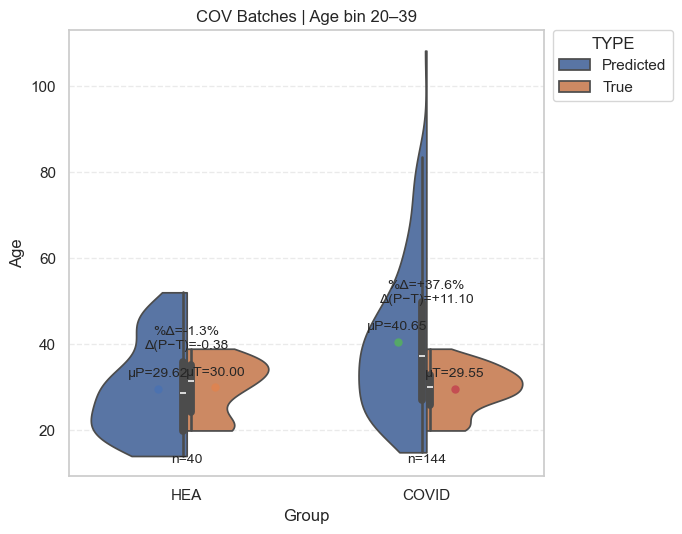

Saved: COV_violin_agebin_20-39.svg


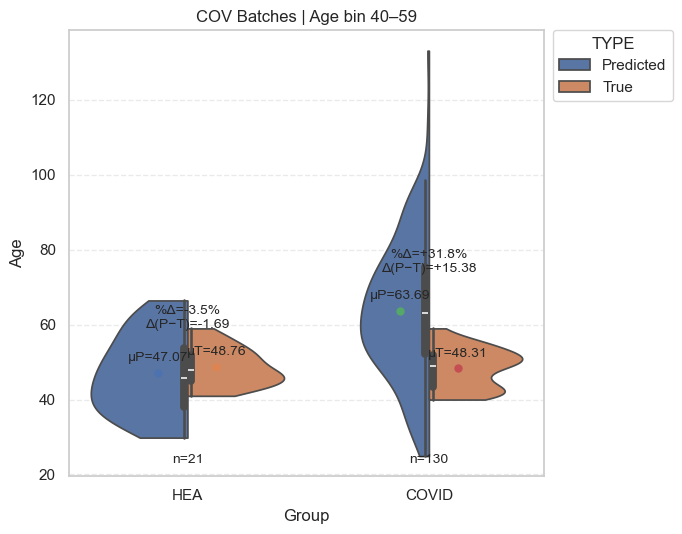

Saved: COV_violin_agebin_40-59.svg


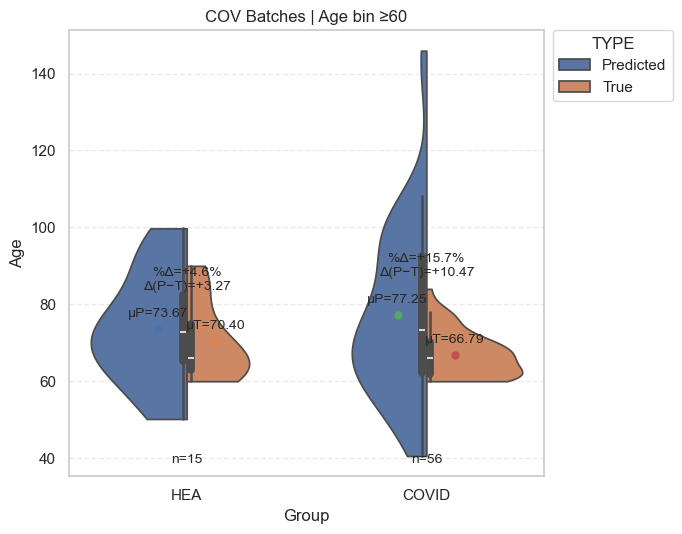

Saved: COV_violin_agebin_ge60.svg


In [272]:
import seaborn as sns

AGE_BINS = [0, 20, 40, 60,120]
AGE_LABELS = ["<20", "20–39", "40–59", "≥60"]

df_cov["age_bin"] = pd.cut(
    df_cov["AGE"],
    bins=AGE_BINS,
    labels=AGE_LABELS,
    right=False,
    include_lowest=True
)

df_cov["age_bin"] = pd.Categorical(df_cov["age_bin"], categories=AGE_LABELS, ordered=True)


def plot_violin_one_agebin(df, age_bin_value):

    df_b = df[df["age_bin"].astype(str) == str(age_bin_value)].copy()

    if len(df_b) == 0:
        print(f"[Skip] age_bin={age_bin_value} (no data)")
        return

    long_df = pd.concat([
        df_b[["DIS_HEA_2", "AGE_pred_weighted"]]
        .rename(columns={"AGE_pred_weighted": "AGE"})
        .assign(TYPE="Predicted"),

        df_b[["DIS_HEA_2", "AGE"]]
        .rename(columns={"AGE": "AGE"})
        .assign(TYPE="True")
    ], axis=0, ignore_index=True)

    long_df["TYPE"] = pd.Categorical(
        long_df["TYPE"],
        categories=["Predicted", "True"],
        ordered=True
    )

    fig, ax = plt.subplots(figsize=(7, 5.5))

    sns.violinplot(
        data=long_df,
        x="DIS_HEA_2",
        y="AGE",
        hue="TYPE",
        hue_order=["Predicted", "True"],
        order=["HEA", "COVID"],
        split=True,
        inner="box",
        cut=0,
        ax=ax
    )

    mean_table = (
        long_df.groupby(["DIS_HEA_2", "TYPE"])["AGE"]
        .mean()
        .unstack("TYPE")
        .reindex(["HEA", "COVID"])
    )

    n_table = (
        df_b["DIS_HEA_2"]
        .value_counts()
        .reindex(["HEA", "COVID"])
        .fillna(0)
        .astype(int)
    )


    x_off = 0.12
    ymin, ymax = ax.get_ylim()
    y_pad = 0.02 * (ymax - ymin)

    for i, grp in enumerate(["HEA", "COVID"]):
        if grp not in mean_table.index:
            continue

        pred_mu = mean_table.loc[grp, "Predicted"] if "Predicted" in mean_table.columns else np.nan
        true_mu = mean_table.loc[grp, "True"] if "True" in mean_table.columns else np.nan
        n_val = n_table.loc[grp] if grp in n_table.index else 0


        if pd.notna(pred_mu):
            ax.scatter(i - x_off, pred_mu, zorder=6, s=25)
            ax.text(
                i - x_off, pred_mu + y_pad,
                f"μP={pred_mu:.2f}",
                ha="center", va="bottom", fontsize=10
            )

        if pd.notna(true_mu):
            ax.scatter(i + x_off, true_mu, zorder=6, s=25)
            ax.text(
                i + x_off, true_mu + y_pad,
                f"μT={true_mu:.2f}",
                ha="center", va="bottom", fontsize=10
            )


        if pd.notna(pred_mu) and pd.notna(true_mu):
            delta = pred_mu - true_mu
            pct = (delta / true_mu * 100.0) if true_mu != 0 else np.nan

            y_top = max(pred_mu, true_mu) + 4 * y_pad

            delta_text = f"Δ(P−T)={delta:+.2f}"
            pct_text = f"%Δ={pct:+.1f}%" if np.isfinite(pct) else "%Δ=nan"

            ax.text(
                i, y_top,
                delta_text,
                ha="center", va="bottom", fontsize=10
            )
            ax.text(
                i, y_top + 1.6 * y_pad,
                pct_text,
                ha="center", va="bottom", fontsize=10
            )


        ax.text(
            i, ymin + 1.2 * y_pad,
            f"n={n_val}",
            ha="center", va="bottom", fontsize=10
        )

    ax.set_title(f"COV Batches | Age bin {age_bin_value}")
    ax.set_xlabel("Group")
    ax.set_ylabel("Age")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend(title="TYPE", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

    plt.tight_layout()

    safe_age_bin = (
        str(age_bin_value)
        .replace("–", "-")
        .replace("≥", "ge")
        .replace("<", "lt")
        .replace(" ", "")
    )
    save_name = f"COV_violin_agebin_{safe_age_bin}.svg"

    plt.savefig(save_name, format="svg", bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {save_name}")

for ab in AGE_LABELS:
    plot_violin_one_agebin(df_cov, ab)

Group
HEA    322
MDD    244
Name: count, dtype: int64


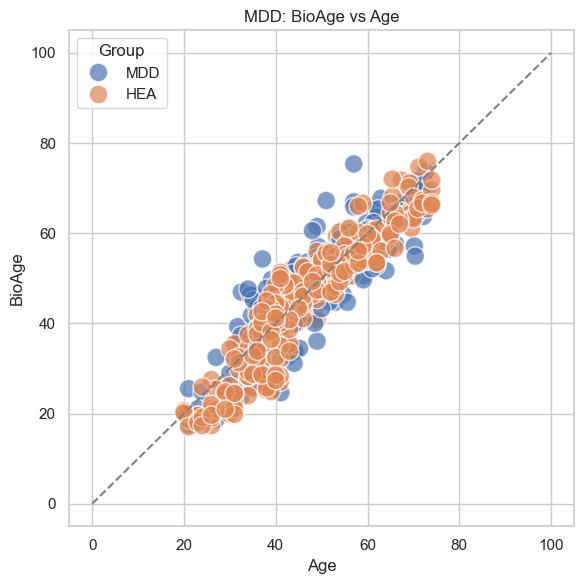

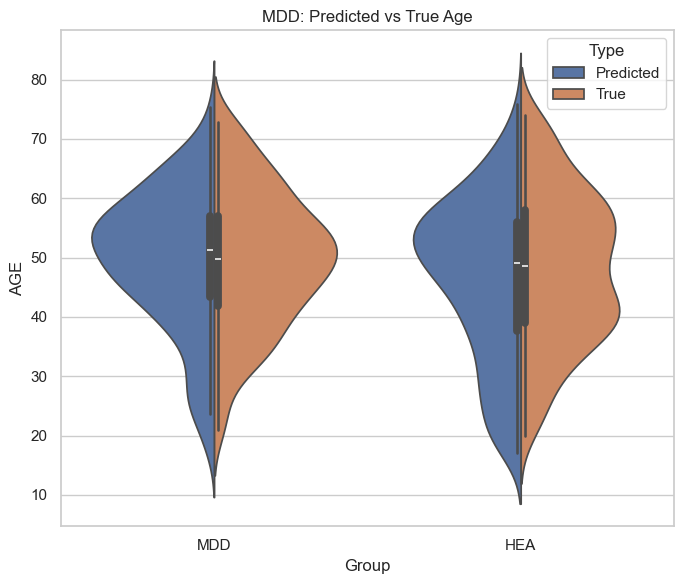

            MAE      RMSE        R2  Spearman       MAD    N
Group                                                       
HEA    3.860841  4.821144  0.857678  0.953965  3.257709  322
MDD    4.200571  5.662698  0.759150  0.889689  3.065988  244
Finished: MDD_overall


In [273]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


sns.set(style="whitegrid")


TARGET_BATCHES = [
    "ETES4(Major depressive Disease samplesorder1)",
    "ETES5(Major depressive Disease samplesorder2)"
]

DISEASE_LABEL = "MDD"
SAVE_PREFIX = "MDD_overall"


def predict_ensemble(X, ensemble, features, weights):

    X = X[features]
    preds = []

    for item in ensemble:

        X_new = item["preprocess"].transform(X)

        if hasattr(X_new, "toarray"):
            X_new = X_new.toarray()

        model = load_plain_dnn_with_fallback(
            item["model_path"],
            item["hyperparameters"],
            X_new.shape[1]
        )

        preds.append(
            model(X_new, training=False)
            .numpy()
            .ravel()
        )

    preds = np.column_stack(preds)

    return preds @ np.asarray(weights), preds



def metrics(y, pred):

    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred),
        "Spearman": spearmanr(y, pred).correlation,
        "MAD": np.median(abs(pred-y)),
        "N": len(y)
    }



df = dat.copy()

df["Batch"] = df["Batch"].astype(str).str.strip()
df["DIS_HEA"] = df["DIS_HEA"].astype(str)


df = df[df["Batch"].isin(TARGET_BATCHES)].copy()


if USE_EXCLUDE_BATCHES:
    df = df[
        ~df["Batch"].isin(EXCLUDE_BATCHES)
    ].copy()


if df.empty:
    raise ValueError("No samples selected")


df["Group"] = np.where(
    df["DIS_HEA"].str.contains("HEA", case=False),
    "HEA",
    DISEASE_LABEL
)


print(df["Group"].value_counts())



df["AGE_pred"] , pred_matrix = predict_ensemble(
    df,
    loaded_ensemble,
    feature_cols_loaded,
    weight_vector
)


df["Error"] = df["AGE_pred"] - df["AGE"]



plt.figure(figsize=(6,6))

sns.scatterplot(
    data=df,
    x="AGE",
    y="AGE_pred",
    hue="Group",
    s=180,
    alpha=0.7
)

plt.plot(
    [0,100],
    [0,100],
    "--",
    color="gray"
)

plt.xlabel("Age")
plt.ylabel("BioAge")
plt.title(f"{DISEASE_LABEL}: BioAge vs Age")

plt.tight_layout()
plt.savefig(
    f"{SAVE_PREFIX}_scatter.svg",
    bbox_inches="tight"
)

plt.show()



plot_df = pd.concat([
    df[["Group","AGE_pred"]]
    .rename(columns={"AGE_pred":"AGE"})
    .assign(Type="Predicted"),

    df[["Group","AGE"]]
    .assign(Type="True")
])


plt.figure(figsize=(7,6))

sns.violinplot(
    data=plot_df,
    x="Group",
    y="AGE",
    hue="Type",
    split=True,
    inner="box"
)

plt.title(
    f"{DISEASE_LABEL}: Predicted vs True Age"
)

plt.tight_layout()

plt.savefig(
    f"{SAVE_PREFIX}_violin.svg",
    bbox_inches="tight"
)

plt.show()


metrics_df = pd.DataFrame([
    {
        "Group":g,
        **metrics(
            d["AGE"],
            d["AGE_pred"]
        )
    }
    for g,d in df.groupby("Group")
]).set_index("Group")


print(metrics_df)



df.to_csv(
    f"{SAVE_PREFIX}_prediction.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Finished:", SAVE_PREFIX)

Group
FLU    352
HEA    137
Name: count, dtype: int64


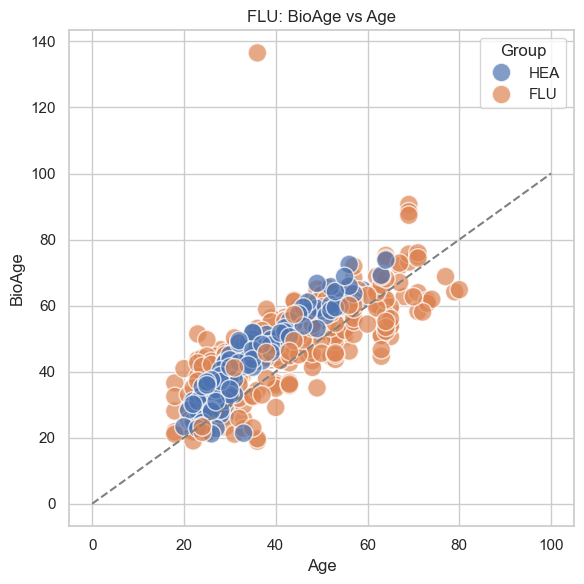

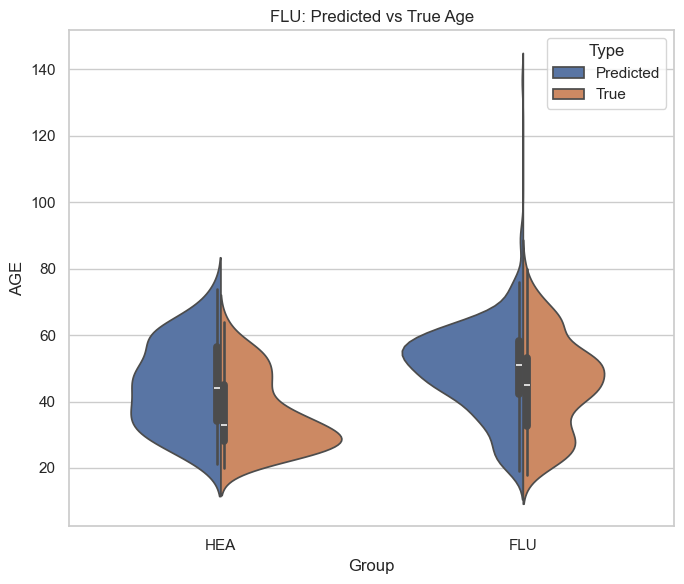

            MAE       RMSE        R2  Spearman       MAD    N
Group                                                        
FLU    8.350841  11.032608  0.390665  0.803756  7.018779  352
HEA    8.829351   9.723894  0.203925  0.933232  9.030474  137
Finished: FLU_


In [274]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


sns.set(style="whitegrid")


TARGET_BATCHES = [
    "ETES3(Influenza3)",
    "ETES1(Influenza1)",
    "ETES2(Influenza1)",
]

DISEASE_LABEL = "FLU"
SAVE_PREFIX = "FLU_"


def predict_ensemble(X, ensemble, features, weights):

    X = X[features]
    preds = []

    for item in ensemble:

        X_new = item["preprocess"].transform(X)

        if hasattr(X_new, "toarray"):
            X_new = X_new.toarray()

        model = load_plain_dnn_with_fallback(
            item["model_path"],
            item["hyperparameters"],
            X_new.shape[1]
        )

        preds.append(
            model(X_new, training=False)
            .numpy()
            .ravel()
        )

    preds = np.column_stack(preds)

    return preds @ np.asarray(weights), preds



def metrics(y, pred):

    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred),
        "Spearman": spearmanr(y, pred).correlation,
        "MAD": np.median(abs(pred-y)),
        "N": len(y)
    }



df = dat.copy()

df["Batch"] = df["Batch"].astype(str).str.strip()
df["DIS_HEA"] = df["DIS_HEA"].astype(str)


df = df[df["Batch"].isin(TARGET_BATCHES)].copy()


if USE_EXCLUDE_BATCHES:
    df = df[
        ~df["Batch"].isin(EXCLUDE_BATCHES)
    ].copy()


if df.empty:
    raise ValueError("No samples selected")


df["Group"] = np.where(
    df["DIS_HEA"].str.contains("HEA", case=False),
    "HEA",
    DISEASE_LABEL
)


print(df["Group"].value_counts())



df["AGE_pred"] , pred_matrix = predict_ensemble(
    df,
    loaded_ensemble,
    feature_cols_loaded,
    weight_vector
)


df["Error"] = df["AGE_pred"] - df["AGE"]



plt.figure(figsize=(6,6))

sns.scatterplot(
    data=df,
    x="AGE",
    y="AGE_pred",
    hue="Group",
    s=180,
    alpha=0.7
)

plt.plot(
    [0,100],
    [0,100],
    "--",
    color="gray"
)

plt.xlabel("Age")
plt.ylabel("BioAge")
plt.title(f"{DISEASE_LABEL}: BioAge vs Age")

plt.tight_layout()
plt.savefig(
    f"{SAVE_PREFIX}_scatter.svg",
    bbox_inches="tight"
)

plt.show()



plot_df = pd.concat([
    df[["Group","AGE_pred"]]
    .rename(columns={"AGE_pred":"AGE"})
    .assign(Type="Predicted"),

    df[["Group","AGE"]]
    .assign(Type="True")
])


plt.figure(figsize=(7,6))

sns.violinplot(
    data=plot_df,
    x="Group",
    y="AGE",
    hue="Type",
    split=True,
    inner="box"
)

plt.title(
    f"{DISEASE_LABEL}: Predicted vs True Age"
)

plt.tight_layout()

plt.savefig(
    f"{SAVE_PREFIX}_violin.svg",
    bbox_inches="tight"
)

plt.show()


metrics_df = pd.DataFrame([
    {
        "Group":g,
        **metrics(
            d["AGE"],
            d["AGE_pred"]
        )
    }
    for g,d in df.groupby("Group")
]).set_index("Group")


print(metrics_df)



df.to_csv(
    f"{SAVE_PREFIX}_prediction.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Finished:", SAVE_PREFIX)

Group
Sep    121
HEA     44
Name: count, dtype: int64


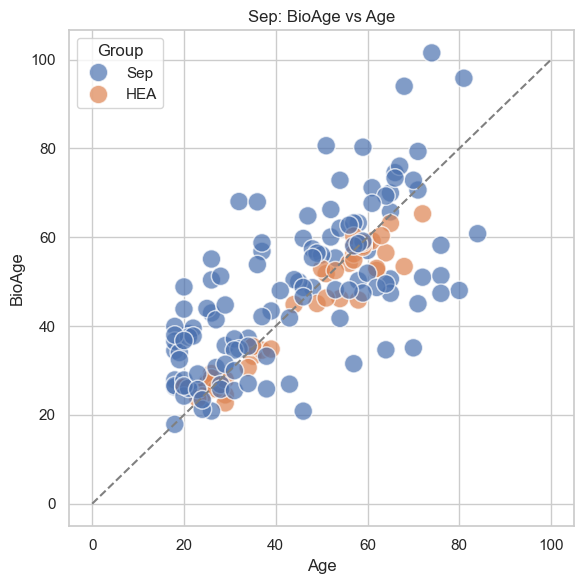

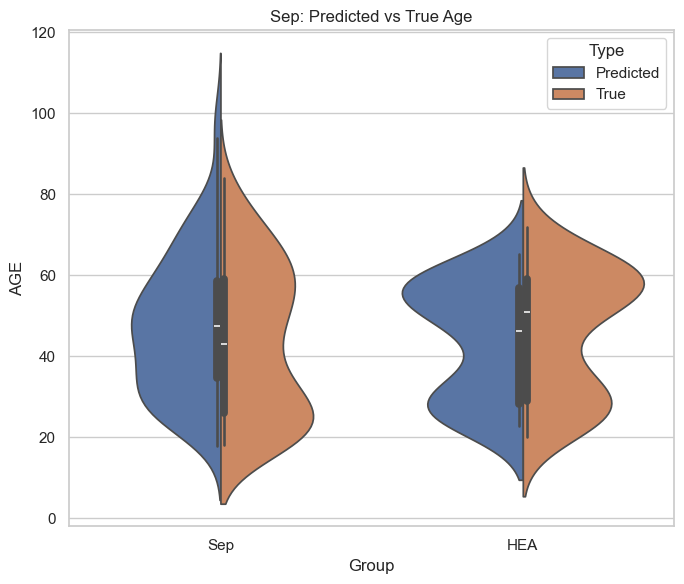

             MAE       RMSE        R2  Spearman       MAD    N
Group                                                         
HEA     3.190005   4.619686  0.909899  0.905673  1.958845   44
Sep    11.732008  14.884562  0.371395  0.691952  8.283626  121
Finished: Sep_


In [275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


sns.set(style="whitegrid")


TARGET_BATCHES = [
    "ES1(Sepsis)"
]

DISEASE_LABEL = "Sep"
SAVE_PREFIX = "Sep_"


def predict_ensemble(X, ensemble, features, weights):

    X = X[features]
    preds = []

    for item in ensemble:

        X_new = item["preprocess"].transform(X)

        if hasattr(X_new, "toarray"):
            X_new = X_new.toarray()

        model = load_plain_dnn_with_fallback(
            item["model_path"],
            item["hyperparameters"],
            X_new.shape[1]
        )

        preds.append(
            model(X_new, training=False)
            .numpy()
            .ravel()
        )

    preds = np.column_stack(preds)

    return preds @ np.asarray(weights), preds



def metrics(y, pred):

    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred),
        "Spearman": spearmanr(y, pred).correlation,
        "MAD": np.median(abs(pred-y)),
        "N": len(y)
    }



df = dat.copy()

df["Batch"] = df["Batch"].astype(str).str.strip()
df["DIS_HEA"] = df["DIS_HEA"].astype(str)


df = df[df["Batch"].isin(TARGET_BATCHES)].copy()


if USE_EXCLUDE_BATCHES:
    df = df[
        ~df["Batch"].isin(EXCLUDE_BATCHES)
    ].copy()


if df.empty:
    raise ValueError("No samples selected")


df["Group"] = np.where(
    df["DIS_HEA"].str.contains("HEA", case=False),
    "HEA",
    DISEASE_LABEL
)


print(df["Group"].value_counts())



df["AGE_pred"] , pred_matrix = predict_ensemble(
    df,
    loaded_ensemble,
    feature_cols_loaded,
    weight_vector
)


df["Error"] = df["AGE_pred"] - df["AGE"]



plt.figure(figsize=(6,6))

sns.scatterplot(
    data=df,
    x="AGE",
    y="AGE_pred",
    hue="Group",
    s=180,
    alpha=0.7
)

plt.plot(
    [0,100],
    [0,100],
    "--",
    color="gray"
)

plt.xlabel("Age")
plt.ylabel("BioAge")
plt.title(f"{DISEASE_LABEL}: BioAge vs Age")

plt.tight_layout()
plt.savefig(
    f"{SAVE_PREFIX}_scatter.svg",
    bbox_inches="tight"
)

plt.show()



plot_df = pd.concat([
    df[["Group","AGE_pred"]]
    .rename(columns={"AGE_pred":"AGE"})
    .assign(Type="Predicted"),

    df[["Group","AGE"]]
    .assign(Type="True")
])


plt.figure(figsize=(7,6))

sns.violinplot(
    data=plot_df,
    x="Group",
    y="AGE",
    hue="Type",
    split=True,
    inner="box"
)

plt.title(
    f"{DISEASE_LABEL}: Predicted vs True Age"
)

plt.tight_layout()

plt.savefig(
    f"{SAVE_PREFIX}_violin.svg",
    bbox_inches="tight"
)

plt.show()


metrics_df = pd.DataFrame([
    {
        "Group":g,
        **metrics(
            d["AGE"],
            d["AGE_pred"]
        )
    }
    for g,d in df.groupby("Group")
]).set_index("Group")


print(metrics_df)



df.to_csv(
    f"{SAVE_PREFIX}_prediction.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Finished:", SAVE_PREFIX)